# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [ ]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [25]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# The zip file is not present, and the CSV is directly available.
# ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
# EXTRACT_DIR = 'heart_ds'
# with zipfile.ZipFile(ZIP_PATH) as zip_ref:
#     zip_ref.extractall(EXTRACT_DIR)

# The user has selected /content/dataset_heart.csv, so I will use that directly.
csv_path = '/content/dataset_heart.csv'  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# Apply column cleaning to standardize names to snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')

# TODO: inspect df
print("DataFrame Head:")
display(df.head())
print("\nDataFrame Info:")
df.info()
print("\nDataFrame Description:")
display(df.describe())

# TODO: identify target column
target = 'heart_disease'  # Updated target to snake_case
print(f"\nTarget column identified: {target}")

# TODO: split features and target
X = df.drop(columns=[target])
y = df[target]

# Remap target values from 1, 2 to 0, 1 for binary classification compatibility
y = y.map({1: 0, 2: 1})

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target (y) value counts after remapping:\n{y.value_counts()}")

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

DataFrame Head:


,age,sex_,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,st_segment,major_vessels,thal,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex_                                  270 non-null    int64  
 2   chest_pain_type                       270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   max_heart_rate                        270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  st_segment                            270 non-null    int64  
 11  ma

,age,sex_,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,st_segment,major_vessels,thal,heart_disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000



Target column identified: heart_disease

Features (X) shape: (270, 13)
Target (y) shape: (270,)
Target (y) value counts after remapping:
heart_disease
0    150
1    120
Name: count, dtype: int64

X_train shape: (216, 13)
X_test shape: (54, 13)
y_train shape: (216,)
y_test shape: (54,)


### Basic visual checks

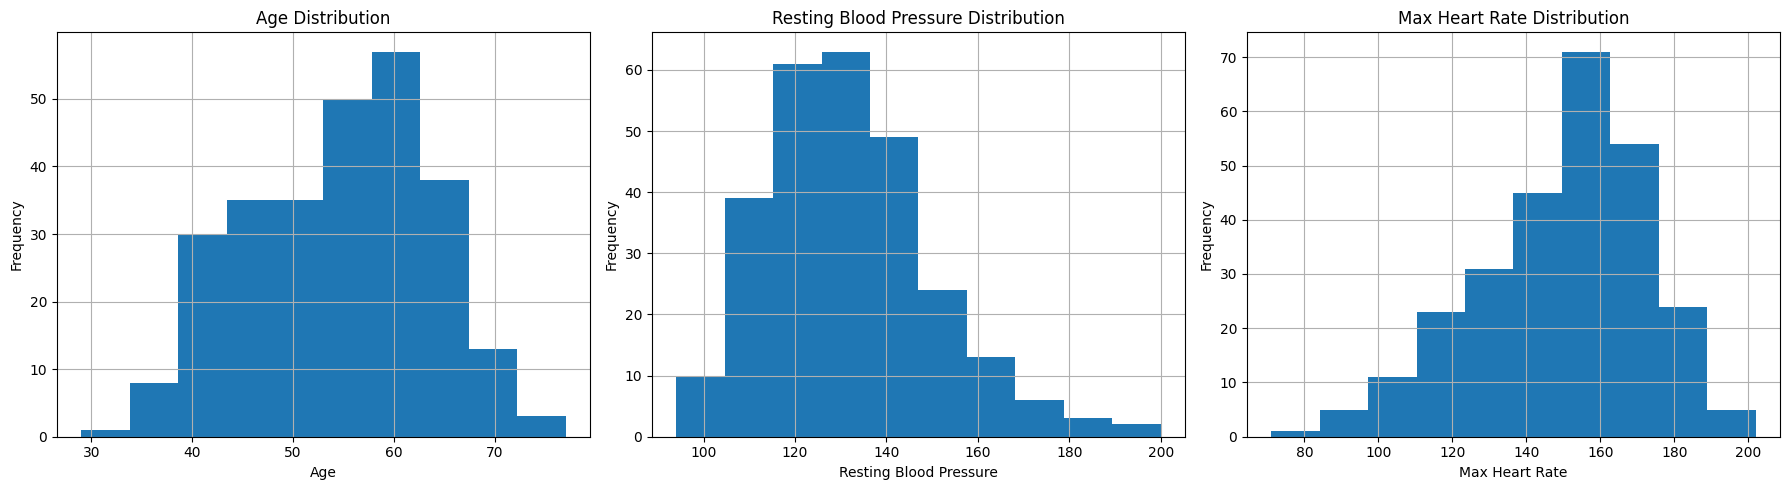

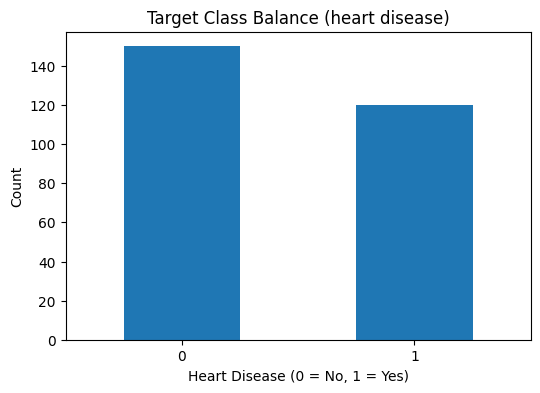

In [27]:
# TODO: pick a few numeric columns and plot histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df['age'].hist(ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

df['resting_blood_pressure'].hist(ax=axes[1])
axes[1].set_title('Resting Blood Pressure Distribution')
axes[1].set_xlabel('Resting Blood Pressure')
axes[1].set_ylabel('Frequency')

df['max_heart_rate'].hist(ax=axes[2])
axes[2].set_title('Max Heart Rate Distribution')
axes[2].set_xlabel('Max Heart Rate')
axes[2].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


# TODO: plot class balance as a bar chart
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar')
plt.title('Target Class Balance (heart disease)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Preprocessing pipeline

In [28]:
cat_cols = ['sex_', 'chest_pain_type', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'exercise_induced_angina', 'st_segment', 'major_vessels', 'thal'] # Updated 'sex' to 'sex_'
num_cols = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'max_heart_rate', 'oldpeak'] # Updated to snake_case

# TODO: build a ColumnTransformer named pre
# Apply OneHotEncoder to categorical columns and StandardScaler to numerical columns
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

## Helper - evaluation function

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='binary', pos_label=1), # pos_label remains 1 after remapping
        'recall': recall_score(y_test, y_pred, average='binary', pos_label=1),     # pos_label remains 1 after remapping
        'f1': f1_score(y_test, y_pred, average='binary', pos_label=1),
    }
    print(f"{name}: {metrics}")

    # TODO: confusion matrix plot
    # Draw with plt.imshow or ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class (assuming it's the second class, which is now 1)
        fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Removed pos_label
        roc_auc = roc_auc_score(y_test, y_prob)          # Removed pos_label

        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {name}')
        plt.legend(loc="lower right")
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic Regression (no grid search): {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


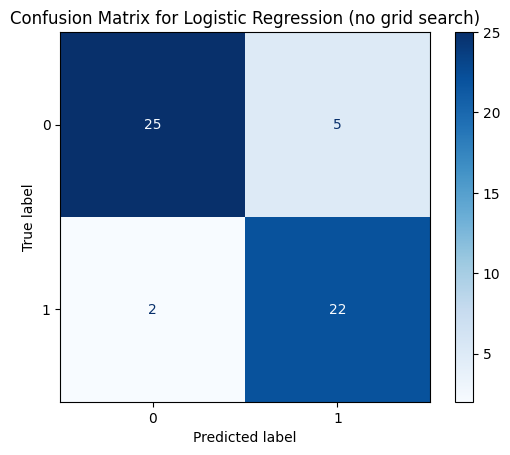

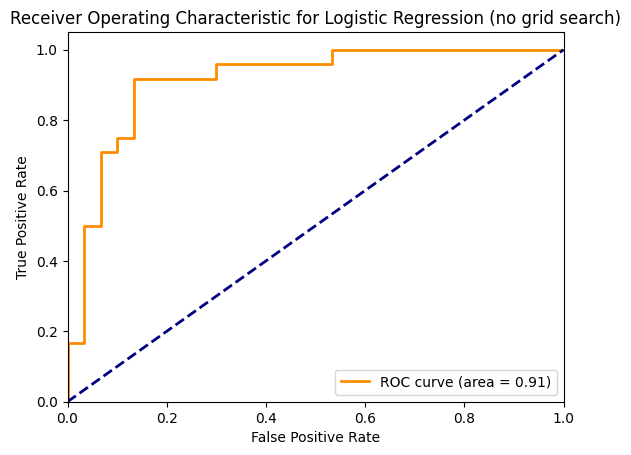

In [32]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=200)) # Increased max_iter
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (no grid search)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}
LR grid: {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


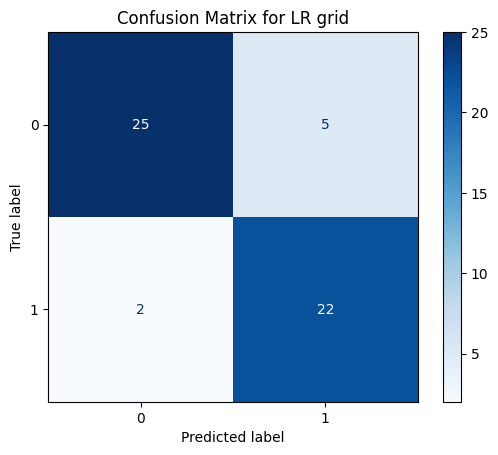

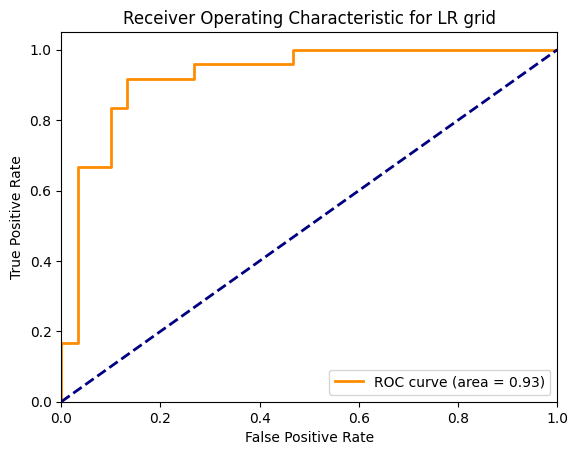

In [34]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('logisticregression', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=200))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

SVM no grid: {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


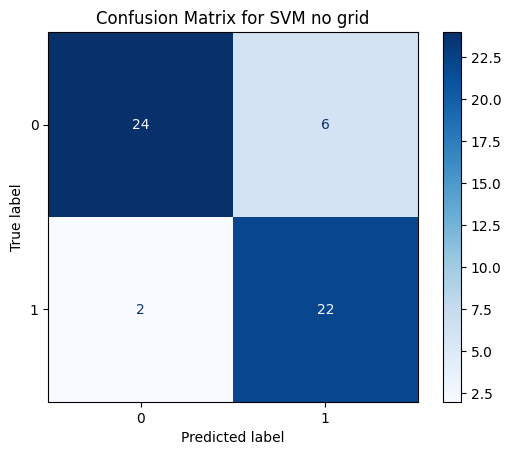

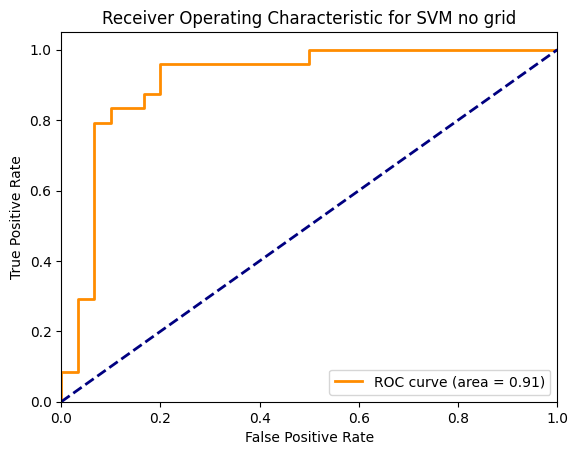

In [35]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
SVM grid: {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


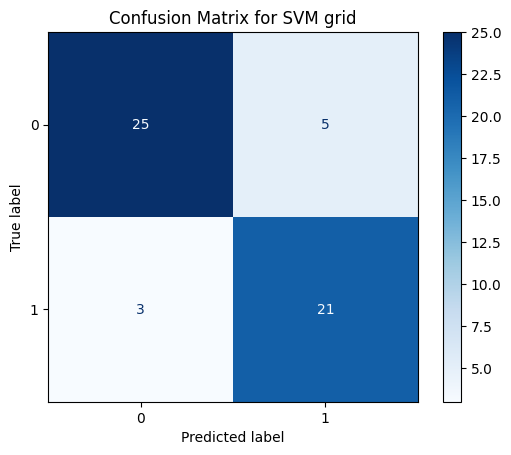

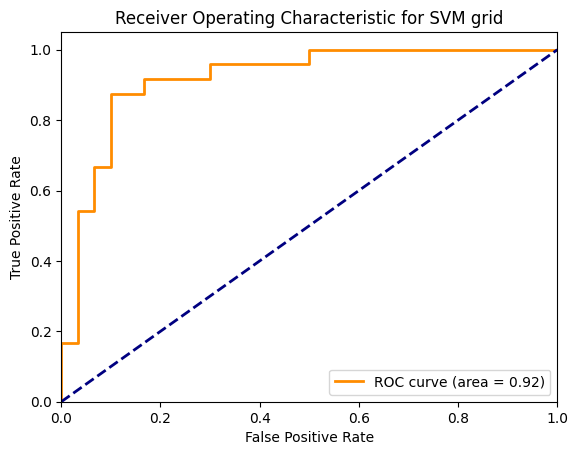

In [36]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svc', SVC(random_state=RANDOM_STATE, probability=True))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svc__kernel': ['rbf', 'linear'],
    'svc__C': [0.01, 0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:39:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB no grid: {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


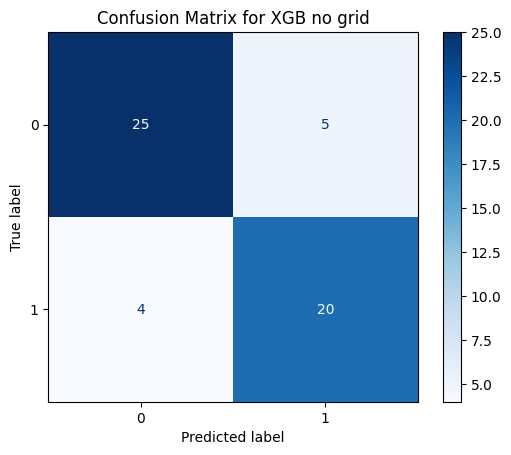

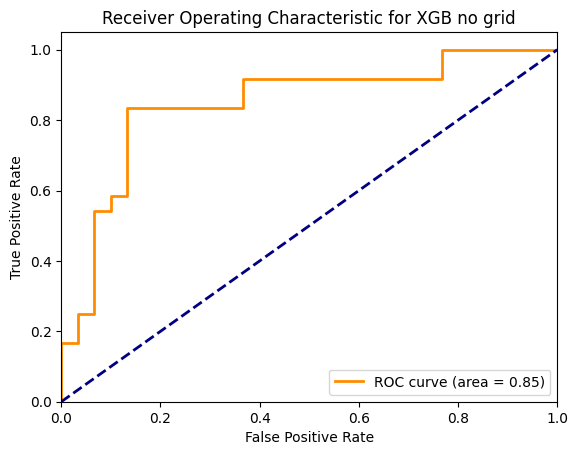

In [37]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgbclassifier', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss'))
])

pipe_xgb.fit(X_train, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__learning_rate': 0.2, 'xgbclassifier__max_depth': 7, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__subsample': 0.8}
XGB grid: {'accuracy': 0.7777777777777778, 'precision': 0.7142857142857143, 'recall': 0.8333333333333334, 'f1': 0.7692307692307693}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:41:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


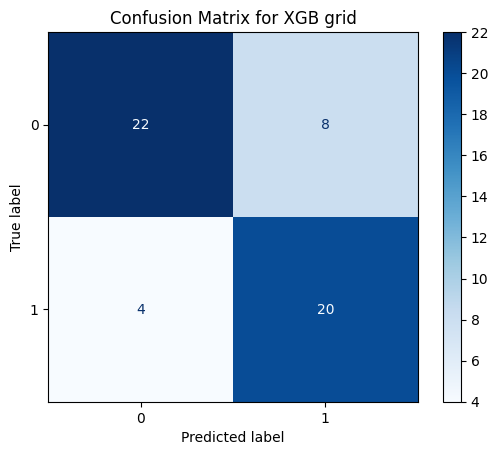

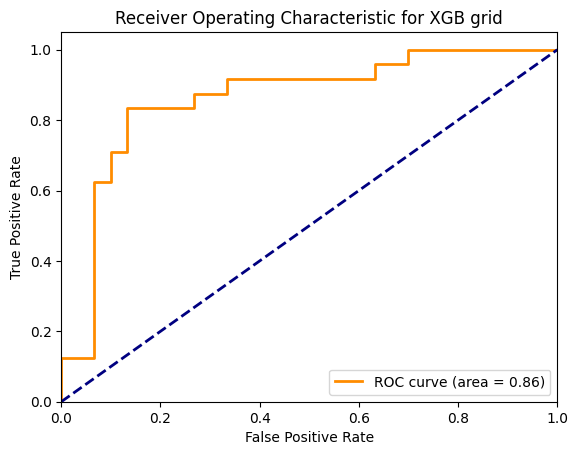

In [38]:
# Re-define pre to ensure it uses the latest cat_cols and num_cols
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgbclassifier', XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss'))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)

## Compare models

In [ ]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary
